# Intelligent Patient Risk Assessment  
## Heart Risk — Full Pipeline (Classification + Regression)

This notebook trains both classification and regression models for heart disease risk prediction and compares their performance.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier

import joblib
import os

print("Libraries loaded")

Libraries loaded


In [ ]:
from google.colab import files
import io

print("Upload feature_engineered_data.csv")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Dataset loaded")
df.head()

📁 Upload feature_engineered_data.csv


Saving feature_engineered_data.csv to feature_engineered_data.csv
Dataset loaded


,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,obesity_risk_score,cholesterol_risk_score,high_bp_flag,bmi_age_interaction,combined_risk_index,age_group_middle,age_group_senior,bmi_category_obese,bmi_category_overweight,bmi_category_underweight
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,57.387241,51.492983,1,1769.0,52.994839,False,True,True,False,False
1,52,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,36.219202,3.984993,1,1201.2,27.620116,False,True,False,False,False
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,42.898797,21.793300,0,1332.0,40.128196,False,True,False,False,False
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,52.194082,22.962029,0,1983.2,49.950427,False,True,False,True,False
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,32.095465,34.296907,0,975.2,26.634294,True,False,False,False,False


In [ ]:
print("Shape:", df.shape)

Shape: (97297, 42)


In [ ]:
target_col = "heart_disease_risk_score"

def risk_category(x):
    if x < 0.33:
        return 0
    elif x < 0.66:
        return 1
    else:
        return 2

df["target_class"] = df[target_col].apply(risk_category)

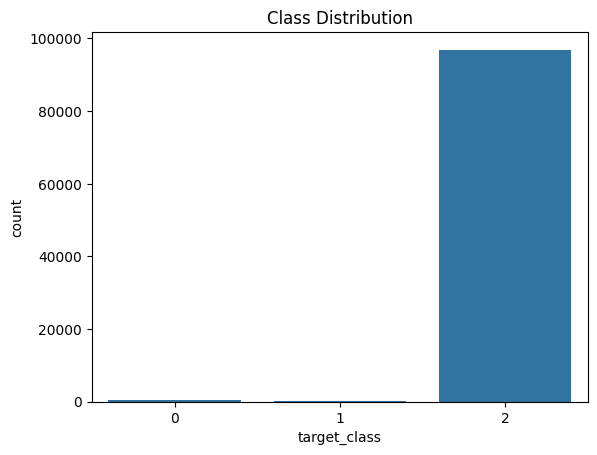

In [ ]:
sns.countplot(x="target_class", data=df)
plt.title("Class Distribution")
plt.show()

In [ ]:
risk_cols = [
    "diabetes_risk_score",
    "heart_disease_risk_score",
    "hypertension_risk_score",
    "obesity_risk_score",
    "cholesterol_risk_score"
]

existing_risks = [c for c in risk_cols if c in df.columns]

y_cls = df["target_class"]
X = df.drop(columns=existing_risks + ["target_class"], errors="ignore")

print("Features ready")

Features ready


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

In [ ]:
X_combined = pd.concat([X_train, X_test])

cat_cols = X_combined.select_dtypes(include="object").columns

if len(cat_cols) > 0:
    X_combined = pd.get_dummies(X_combined, columns=cat_cols, drop_first=True)

X_train = X_combined.iloc[:len(X_train)]
X_test = X_combined.iloc[len(X_train):]

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
dt_model = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, random_state=42)

In [ ]:
def eval_cls(name, model, scaled=False):
    if scaled:
        preds = model.predict(X_test_scaled)
    else:
        preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="weighted")

    print(f"{name} → Accuracy: {acc:.4f}, F1: {f1:.4f}")

In [ ]:
eval_cls("Logistic Regression", log_model, scaled=True)
eval_cls("Decision Tree", dt_model)

Logistic Regression → Accuracy: 0.9966, F1: 0.9955
Decision Tree → Accuracy: 0.9956, F1: 0.9945


In [ ]:
best_cls_model = log_model
print("Best classification model: Logistic Regression")

Best classification model: Logistic Regression


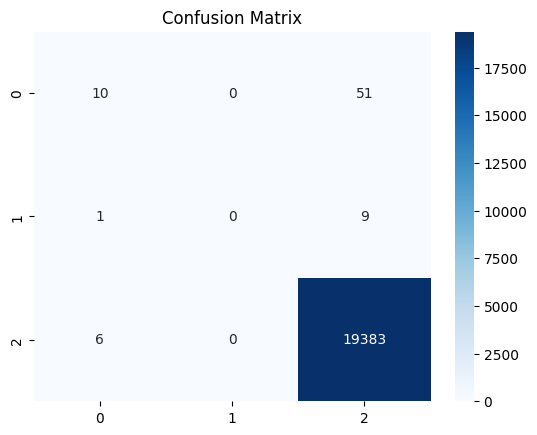

In [ ]:
y_pred_cls = best_cls_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_cls)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(y_test, y_pred_cls))

              precision    recall  f1-score   support

           0       0.59      0.16      0.26        61
           1       0.00      0.00      0.00        10
           2       1.00      1.00      1.00     19389

    accuracy                           1.00     19460
   macro avg       0.53      0.39      0.42     19460
weighted avg       1.00      1.00      1.00     19460



In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred_cls, average="weighted")
recall = recall_score(y_test, y_pred_cls, average="weighted")
f1 = f1_score(y_test, y_pred_cls, average="weighted")

print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Precision: 0.9951
Recall   : 0.9966
F1 Score : 0.9955


### ROC-AUC Score

In [ ]:

y_prob_cls = best_cls_model.predict_proba(X_test_scaled)

roc_auc = roc_auc_score(y_test, y_prob_cls, multi_class="ovr")
print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.9913


### ROC Curve

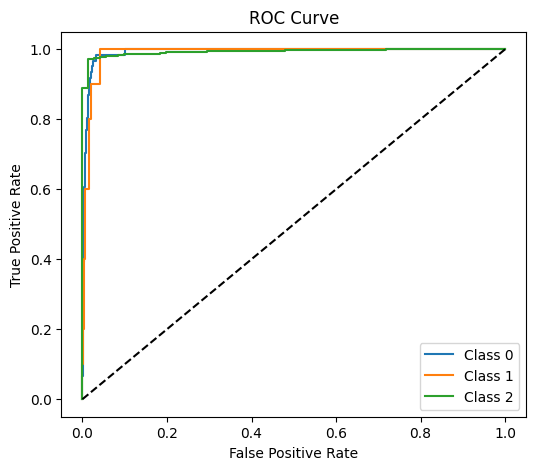

In [ ]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0,1,2])

plt.figure(figsize=(6,5))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_cls[:, i])
    plt.plot(fpr, tpr, label=f"Class {i}")

plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Prepare Regression Target

In [ ]:
y_reg = df[target_col]
X_reg = df.drop(columns=existing_risks, errors="ignore")

### Regression Split

In [ ]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg,
    test_size=0.2,
    random_state=42
)

### Encode Regression Features

In [ ]:
Xr_combined = pd.concat([Xr_train, Xr_test])

cat_cols = Xr_combined.select_dtypes(include="object").columns

if len(cat_cols) > 0:
    Xr_combined = pd.get_dummies(Xr_combined, columns=cat_cols, drop_first=True)

Xr_train = Xr_combined.iloc[:len(Xr_train)]
Xr_test = Xr_combined.iloc[len(Xr_train):]

### Regression Scaling

In [ ]:
scaler_reg = StandardScaler()

Xr_train_scaled = scaler_reg.fit_transform(Xr_train)
Xr_test_scaled = scaler_reg.transform(Xr_test)

### Linear Regression

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(Xr_train_scaled, yr_train)

print("Linear Regression trained")

Linear Regression trained


### Regression Predictions

In [ ]:
yr_pred = lin_reg.predict(Xr_test_scaled)

### Regression Metrics

In [ ]:
mae = mean_absolute_error(yr_test, yr_pred)
mse = mean_squared_error(yr_test, yr_pred)
rmse = np.sqrt(mse)
r2 = r2_score(yr_test, yr_pred)

print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2  : {r2:.4f}")

MAE : 2.5217
RMSE: 3.1838
R2  : 0.9575


### Actual vs Predicted Plot

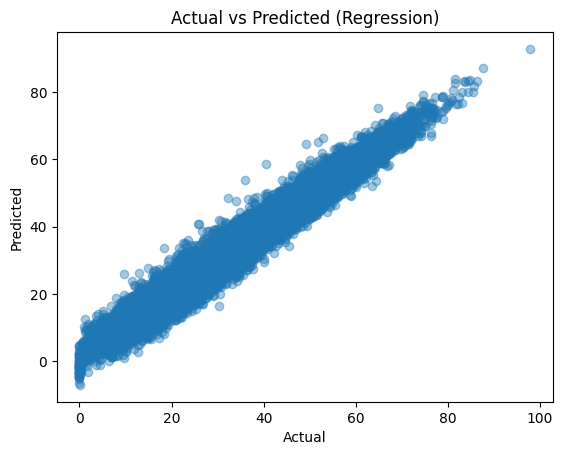

In [ ]:
plt.scatter(yr_test, yr_pred, alpha=0.4)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Regression)")
plt.show()

In [ ]:
cv_scores = cross_val_score(
    best_cls_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="f1_weighted"
)

print("Mean CV F1:", cv_scores.mean())

Mean CV F1: 0.9954431011891817


In [ ]:
print("Train acc:", best_cls_model.score(X_train_scaled, y_train))
print("Test acc :", best_cls_model.score(X_test_scaled, y_test))

Train acc: 0.9966339915464368
Test acc : 0.9965570400822199


In [ ]:
print("CLASSIFICATION RESULTS")

eval_cls("Logistic Regression", log_model, scaled=True)
eval_cls("Decision Tree", dt_model)

print("\nREGRESSION RESULTS")

print(f"Linear Regression → RMSE: {rmse:.4f}, R2: {r2:.4f}")

print("\nFinal Selection:")
print("• Best Classification Model → Logistic Regression")
print("• Best Regression Model → Linear Regression")

CLASSIFICATION RESULTS
Logistic Regression → Accuracy: 0.9966, F1: 0.9955
Decision Tree → Accuracy: 0.9956, F1: 0.9945

REGRESSION RESULTS
Linear Regression → RMSE: 3.1838, R2: 0.9575

Final Selection:
• Best Classification Model → Logistic Regression
• Best Regression Model → Linear Regression


In [ ]:
os.makedirs("models", exist_ok=True)

In [ ]:
joblib.dump(best_cls_model, "models/heart_cls_model.pkl")

In [ ]:
joblib.dump(lin_reg, "models/heart_reg_model.pkl")

In [ ]:
joblib.dump(scaler, "models/heart_scaler.pkl")
joblib.dump(scaler_reg, "models/heart_scaler_reg.pkl")

In [ ]:
from google.colab import files

files.download("models/heart_cls_model.pkl")
files.download("models/heart_reg_model.pkl")

## Heart Risk Pipeline Completed

Both classification and regression models were trained and evaluated.

- Classification → risk category prediction  
- Regression → exact risk score prediction

The system is ready for Streamlit deployment.